# BENZOATE LOCAL ANESTHETIC SAR RE-ANALYSIS
## ChEMBL-Based Structural Validation

### Research Overview

This project extends a previous SAR re-analysis of a 16-compound series of benzoate local anesthetics originally studied by Zou, Chen, and Zhou (2019).

The previous analysis proposed that anesthetic activity is influenced by an interaction among three structural variables:

- **R** — alkyl chain length
- **X1** — linker identity
- **X2** — terminal-ring heteroatom

The central hypothesis is that the effects of **R** and **X1** depend on the identity of **X2**, rather than each structural variable acting independently.

### Objective

The goal of this phase is to identify additional experimentally tested molecules from **ChEMBL** that are sufficiently structurally similar to the original compounds to allow this SAR hypothesis to be examined beyond the original 16-compound series.

The search will focus on the overall three-part architecture of the target compounds:

1. **Lipophilic section** — the aromatic/lipophilic portion
2. **Link section** — the connecting region between the aromatic and terminal-ring sections
3. **Hydrophilic section** — the terminal six-membered heterocyclic region

The exact structural matching criteria will be developed and refined as the ChEMBL data are examined.

### Research Approach

The general workflow will be:

**Original 16-compound SAR**  
→ **Search ChEMBL for structurally related compounds**  
→ **Evaluate similarity across the three structural sections**  
→ **Identify suitable molecules for SAR comparison**  
→ **Apply the existing R × X1 × X2 hypothesis**  
→ **Determine whether the additional molecules support, challenge, or extend the original findings**

This is a **chemistry and SAR validation study**, not an AI or machine-learning project. Python, ChEMBL, and cheminformatics tools will be used primarily to retrieve, organize, compare, and analyze experimentally reported chemical structures and activity data.

In [1]:
!pip install chembl_webresource_client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 792.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.9 MB/s eta 0:00:00


## Step 1 — Retrieve Nav1.7 Activity Data from ChEMBL

This step connects to the ChEMBL database, identifies the **human Nav1.7 (SCN9A) single-protein target**, and retrieves its associated biological activity records.

The resulting raw dataset is saved for subsequent analysis.

In [2]:
from chembl_webresource_client.new_client import new_client
import pandas as pd

# ============================================================
# STEP 1 — Retrieve ChEMBL activity data for human Nav1.7
# ============================================================
#
# Purpose:
# Establish the biological activity dataset that will later
# be searched for molecules structurally relevant to the
# benzoate local anesthetic SAR hypothesis.
#
# At this stage, we are NOT filtering for structural similarity.
# We first retrieve the appropriate biological target and its
# associated activity records.
# ============================================================


# ------------------------------------------------------------
# 1. Connect to the ChEMBL Target API
# ------------------------------------------------------------

target_api = new_client.target


# ------------------------------------------------------------
# 2. Search ChEMBL for Nav1.7 targets
# ------------------------------------------------------------

target_query = target_api.search("Nav1.7")
targets_df = pd.DataFrame.from_dict(target_query)

print(f"Number of Nav1.7-related targets found: {len(targets_df)}")


# ------------------------------------------------------------
# 3. Restrict the search to:
#    • SINGLE PROTEIN targets
#    • Homo sapiens
#
# This is intended to focus the analysis on human Nav1.7
# rather than target complexes, cell systems, or non-human
# Nav1.7 proteins.
# ------------------------------------------------------------

human_targets = targets_df[
    (targets_df["target_type"] == "SINGLE PROTEIN") &
    (targets_df["organism"] == "Homo sapiens")
].copy()


# Display the candidates so that the selected target can be
# verified rather than assuming the first search result is correct.

print("\nHuman SINGLE PROTEIN Nav1.7 targets:")
display(
    human_targets[
        ["target_chembl_id", "pref_name", "organism", "target_type"]
    ]
)


# ------------------------------------------------------------
# 4. Select the Nav1.7 target
#
# CHEMBL4794 is typically the ChEMBL target ID for human Nav1.7.
# We will verify the returned target before proceeding.
# ------------------------------------------------------------

if human_targets.empty:
    raise ValueError("No human SINGLE PROTEIN Nav1.7 target was found.")

target_chembl_id = human_targets.iloc[0]["target_chembl_id"]

print(f"\nSelected target ID: {target_chembl_id}")


# ------------------------------------------------------------
# 5. Connect to the ChEMBL Activity API
# ------------------------------------------------------------

activity_api = new_client.activity


# ------------------------------------------------------------
# 6. Retrieve activity records associated with human Nav1.7
#
# These are the RAW records.
# We will preserve them before applying any cleaning or
# filtering criteria in later steps.
# ------------------------------------------------------------

res = activity_api.filter(
    target_chembl_id=target_chembl_id
)

raw_df = pd.DataFrame.from_dict(res)

print(f"Total raw activity records retrieved: {len(raw_df)}")


# Keep the original dataset unchanged.
# All subsequent cleaning/filtering should be performed on
# copies of raw_df so that the original ChEMBL retrieval
# remains available for reference.

Number of Nav1.7-related targets found: 8

Human SINGLE PROTEIN Nav1.7 targets:


,target_chembl_id,pref_name,organism,target_type
2,CHEMBL4296,Sodium channel protein type 9 subunit alpha,Homo sapiens,SINGLE PROTEIN



Selected target ID: CHEMBL4296
Total raw activity records retrieved: 17017


## Step 2 — Preserve and Export the Raw ChEMBL Dataset

This step saves the raw ChEMBL dataset as a CSV file and downloads a local copy.

This avoids repeatedly querying and downloading the same dataset from ChEMBL during subsequent analysis.

In [3]:
from google.colab import files

# ============================================================
# STEP 2 — Preserve and export the raw ChEMBL dataset
# ============================================================
#
# The raw Nav1.7 activity dataset is preserved before any
# filtering or structural selection is performed.
#
# This provides a reproducible record of the original ChEMBL
# retrieval and allows the dataset to be re-examined later
# if our filtering criteria change.
# ============================================================


# Save the raw ChEMBL activity records as a CSV file.
raw_df.to_csv("chembl_nav17_raw_data.csv", index=False)


# Download a local copy for backup and record keeping.
files.download("chembl_nav17_raw_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 3 — Upload the Saved ChEMBL Dataset

This step uploads the previously saved ChEMBL CSV file from local storage and loads it into a pandas DataFrame for analysis.

In [2]:
from google.colab import files
import io
import pandas as pd

# ============================================================
# STEP 3 — Upload the previously saved ChEMBL dataset
# ============================================================

# 1. Open the upload prompt and select the saved CSV file
uploaded = files.upload()

# 2. Make sure a file was uploaded
if not uploaded:
    raise ValueError("No file was uploaded.")

# 3. Get the uploaded filename automatically
file_name = list(uploaded.keys())[0]

# 4. Read the CSV file into a pandas DataFrame
raw_df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# 5. Confirm that the dataset was loaded successfully
print(f"Loaded: {file_name}")
print(f"Rows: {len(raw_df):,}")
print(f"Columns: {len(raw_df.columns):,}")

Saving chembl_nav17_raw_data.csv to chembl_nav17_raw_data.csv
Loaded: chembl_nav17_raw_data.csv
Rows: 17,017
Columns: 47


/tmp/ipykernel_2726/139409442.py:20: DtypeWarning: Columns (1,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df = pd.read_csv(io.BytesIO(uploaded[file_name]))


## Step 4 — Filter and Standardize Activity Data

This step selects exact, reported **IC50 measurements in nM** with valid activity values and canonical SMILES, then retains the key fields needed for subsequent analysis.

In [3]:
# ============================================================
# STEP 4 — Filter and standardize activity data
# ============================================================

# 1. Keep only records with:
#    • IC50 activity measurements
#    • values reported in nM
#    • exact measured values (standard_relation = '=')
#    • a valid numerical activity value
#    • an available canonical SMILES
#
# Using exact IC50 values helps keep the activity dataset
# consistent for later comparison.

processed_df = raw_df[
    raw_df["standard_type"].eq("IC50") &
    raw_df["standard_units"].eq("nM") &
    raw_df["standard_relation"].eq("=") &
    raw_df["standard_value"].notna() &
    raw_df["canonical_smiles"].notna()
].copy()


# 2. Convert activity values to numeric format.
#    errors='coerce' safely converts unexpected non-numeric
#    entries to NaN rather than causing the code to fail.

processed_df["standard_value"] = pd.to_numeric(
    processed_df["standard_value"],
    errors="coerce"
)


# 3. Remove any records that could not be converted to a
#    valid numerical IC50 value.

processed_df = processed_df[
    processed_df["standard_value"].notna()
].copy()


# 4. Keep only the fields needed for the next stages
#    of the analysis.

final_data = processed_df[
    [
        "molecule_chembl_id",
        "canonical_smiles",
        "standard_type",
        "standard_value",
        "standard_units"
    ]
].copy()


# 5. Display the first few records as a quick check.

display(final_data.head())

,molecule_chembl_id,canonical_smiles,standard_type,standard_value,standard_units
0,CHEMBL360307,NS(=O)(=O)c1ccccc1-c1ccc(CNC(=O)c2ccccc2C(=O)N...,IC50,2200.0,nM
2,CHEMBL183380,NS(=O)(=O)c1ccccc1-c1ccc(CNC(=O)c2cccc(C(=O)NC...,IC50,2900.0,nM
4,CHEMBL359815,CC(NC(=O)[C@H]1CCC[C@@H]1C(=O)NCc1ccc(-c2ccccc...,IC50,10000.0,nM
5,CHEMBL179838,CN(Cc1ccc(-c2cccs2)s1)C(=O)[C@H]1CCC[C@@H]1C(=...,IC50,5300.0,nM
6,CHEMBL362660,CC(NC(=O)[C@H]1CCC[C@@H]1C(=O)NCc1ccc(-c2cccs2...,IC50,1400.0,nM


In [4]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 51.8 MB/s eta 0:00:00


## Step 5 — Screen ChEMBL for Structurally Similar Molecules

This step uses RDKit Morgan fingerprints and Tanimoto similarity to compare the 16 reference compounds from the original SAR study against the cleaned ChEMBL Nav1.7 dataset.

Molecules exceeding the selected similarity threshold are retained as candidate structurally similar compounds for further analysis.

In [5]:
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs
import pandas as pd

# ============================================================
# STEP 5 — Screen ChEMBL for structurally similar molecules
# ============================================================
#
# Purpose:
# Compare the 16 reference compounds from the original SAR
# study against the cleaned ChEMBL Nav1.7 dataset.
#
# RDKit Morgan fingerprints are used to represent molecular
# structure, and Tanimoto similarity is used to quantify
# structural similarity.
# ============================================================


# ------------------------------------------------------------
# 1. Initialize the Morgan fingerprint generator
#
# radius = 2 corresponds to the commonly used Morgan/ECFP4
# fingerprint.
# ------------------------------------------------------------

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)


# ------------------------------------------------------------
# 2. Define the structural components used to construct the
#    16 reference compounds.
# ------------------------------------------------------------

R_groups = {
    "C3H7": "CCC",
    "C4H9": "CCCC"
}

X1_groups = {
    "NH": "NC1=CC=C(C=C1)C(=O)OCCN",
    "O": "OC1=CC=C(C=C1)C(=O)OCCN"
}

X2_groups = {
    "C": "2CCCCC2",
    "N": "2CCNCC2",
    "O": "2CCOCC2",
    "S": "2CCSCC2"
}


# ------------------------------------------------------------
# 3. Build the 16 reference compounds programmatically
# ------------------------------------------------------------

compounds = {}

for r_name, r_smiles in R_groups.items():
    for x1_name, x1_smiles in X1_groups.items():
        for x2_name, x2_smiles in X2_groups.items():

            if r_name == "C3H7":
                index = (
                    list(X1_groups.keys()).index(x1_name) * 4
                    + list(X2_groups.keys()).index(x2_name)
                )
                label = f"4{chr(97 + index)}"

            else:
                index = (
                    list(X1_groups.keys()).index(x1_name) * 4
                    + list(X2_groups.keys()).index(x2_name)
                )
                label = f"4{chr(105 + index)}"

            smiles = f"{r_smiles}{x1_smiles}{x2_smiles}"
            compounds[label] = smiles


# ------------------------------------------------------------
# 4. Generate Morgan fingerprints for the 16 reference
#    compounds.
# ------------------------------------------------------------

compound_fps = {}

for label, smiles in compounds.items():
    mol = Chem.MolFromSmiles(smiles)

    if mol:
        compound_fps[label] = morgan_gen.GetFingerprint(mol)
    else:
        print(f"WARNING: Invalid SMILES for {label}: {smiles}")


# ------------------------------------------------------------
# 5. Pre-compute fingerprints for the cleaned ChEMBL dataset.
#
# Doing this once avoids repeatedly generating fingerprints
# while comparing each of the 16 reference compounds.
# ------------------------------------------------------------

print("Pre-computing database fingerprints...")

local_fps = []

for smiles in processed_df["canonical_smiles"]:
    try:
        mol = Chem.MolFromSmiles(smiles)

        if mol:
            local_fps.append(morgan_gen.GetFingerprint(mol))
        else:
            local_fps.append(None)

    except Exception:
        local_fps.append(None)


# ------------------------------------------------------------
# 6. Compare every reference compound against every ChEMBL
#    molecule using Tanimoto similarity.
# ------------------------------------------------------------

summary_results = {}
all_matches = {}

# This is the global similarity threshold.
# We can evaluate whether this value is appropriate later.
similarity_cutoff = 0.30


for label, q_fp in compound_fps.items():

    scores = []

    for fp in local_fps:

        if fp is not None and q_fp is not None:
            scores.append(
                DataStructs.TanimotoSimilarity(q_fp, fp)
            )
        else:
            scores.append(0.0)


    # Copy the processed dataset and attach similarity scores.
    temp_df = processed_df.copy()
    temp_df["similarity"] = scores


    # Retain molecules exceeding the selected similarity threshold.
    hits = (
        temp_df[
            temp_df["similarity"] >= similarity_cutoff
        ]
        .sort_values(
            by="similarity",
            ascending=False
        )
        .copy()
    )


    # Record a summary for this reference compound.
    max_score = max(scores) if scores else 0.0

    summary_results[label] = {
        "Compound": label,
        "SMILES": compounds[label],
        "Max Similarity": round(max_score, 4),
        "Hits Count": len(hits)
    }


    # Save matching molecules for later analysis.
    if len(hits) > 0:

        hits["query_compound"] = label

        all_matches[label] = hits[
            [
                "query_compound",
                "molecule_chembl_id",
                "canonical_smiles",
                "similarity",
                "standard_value",
                "standard_units",
                "document_chembl_id",
                "document_year"
            ]
        ]


# ------------------------------------------------------------
# 7. Create a summary table showing how many ChEMBL molecules
#    were identified for each reference compound.
# ------------------------------------------------------------

summary_df = pd.DataFrame.from_dict(
    summary_results,
    orient="index"
).reset_index(drop=True)

print("\n=== SCREENING SUMMARY ===")
display(summary_df)

Pre-computing database fingerprints...

=== SCREENING SUMMARY ===


,Compound,SMILES,Max Similarity,Hits Count
0,4a,CCCNC1=CC=C(C=C1)C(=O)OCCN2CCCCC2,0.5098,12
1,4b,CCCNC1=CC=C(C=C1)C(=O)OCCN2CCNCC2,0.4906,6
2,4c,CCCNC1=CC=C(C=C1)C(=O)OCCN2CCOCC2,0.4906,12
3,4d,CCCNC1=CC=C(C=C1)C(=O)OCCN2CCSCC2,0.4906,6
4,4e,CCCOC1=CC=C(C=C1)C(=O)OCCN2CCCCC2,0.3393,10
5,4f,CCCOC1=CC=C(C=C1)C(=O)OCCN2CCNCC2,0.3333,8
6,4g,CCCOC1=CC=C(C=C1)C(=O)OCCN2CCOCC2,0.3333,13
7,4h,CCCOC1=CC=C(C=C1)C(=O)OCCN2CCSCC2,0.3276,7
8,4i,CCCCNC1=CC=C(C=C1)C(=O)OCCN2CCCCC2,0.6122,8
9,4j,CCCCNC1=CC=C(C=C1)C(=O)OCCN2CCNCC2,0.5882,6


In [6]:
all_matches




{'4a':      query_compound molecule_chembl_id  \
 520              4a          CHEMBL698   
 890              4a          CHEMBL698   
 954              4a          CHEMBL698   
 3110             4a          CHEMBL698   
 3111             4a          CHEMBL698   
 7660             4a          CHEMBL698   
 9944             4a      CHEMBL3688078   
 4442             4a      CHEMBL3688078   
 9890             4a      CHEMBL3688060   
 4424             4a      CHEMBL3688060   
 4420             4a      CHEMBL3688056   
 9878             4a      CHEMBL3688056   
 
                                        canonical_smiles  similarity  \
 520                        CCCCNc1ccc(C(=O)OCCN(C)C)cc1    0.509804   
 890                        CCCCNc1ccc(C(=O)OCCN(C)C)cc1    0.509804   
 954                        CCCCNc1ccc(C(=O)OCCN(C)C)cc1    0.509804   
 3110                       CCCCNc1ccc(C(=O)OCCN(C)C)cc1    0.509804   
 3111                       CCCCNc1ccc(C(=O)OCCN(C)C)cc1    0.509804   
 

## Step 6 — Save the Similarity Screening Results

This step combines the identified ChEMBL hits into a single dataset and saves a local CSV copy for later analysis.

In [7]:
from google.colab import files
import pandas as pd

# ============================================================
# STEP 6 — Save the similarity screening results
# ============================================================

# 1. Combine the matching molecules from all 16 reference
#    compounds into one table.

if not all_matches:
    raise ValueError("No molecules passed the similarity cutoff.")

master_hits_df = pd.concat(
    all_matches.values(),
    ignore_index=True
)


# 2. Save the combined results as a CSV file in the
#    temporary Colab workspace.

output_file = "nav17_similar_compounds.csv"

master_hits_df.to_csv(
    output_file,
    index=False
)


# 3. Display a quick confirmation before downloading.

print(f"Saved {len(master_hits_df):,} matching records to {output_file}")


# 4. Download the results to the local computer.

files.download(output_file)

Saved 143 matching records to nav17_similar_compounds.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 7 — Visualize Unique Matched Molecules

This step removes duplicate ChEMBL molecules and generates a visual grid of the unique matched structures for structural inspection.

Unique ChEMBL molecules identified: 13
Valid molecules drawn: 13
Missing/invalid structures skipped: 0


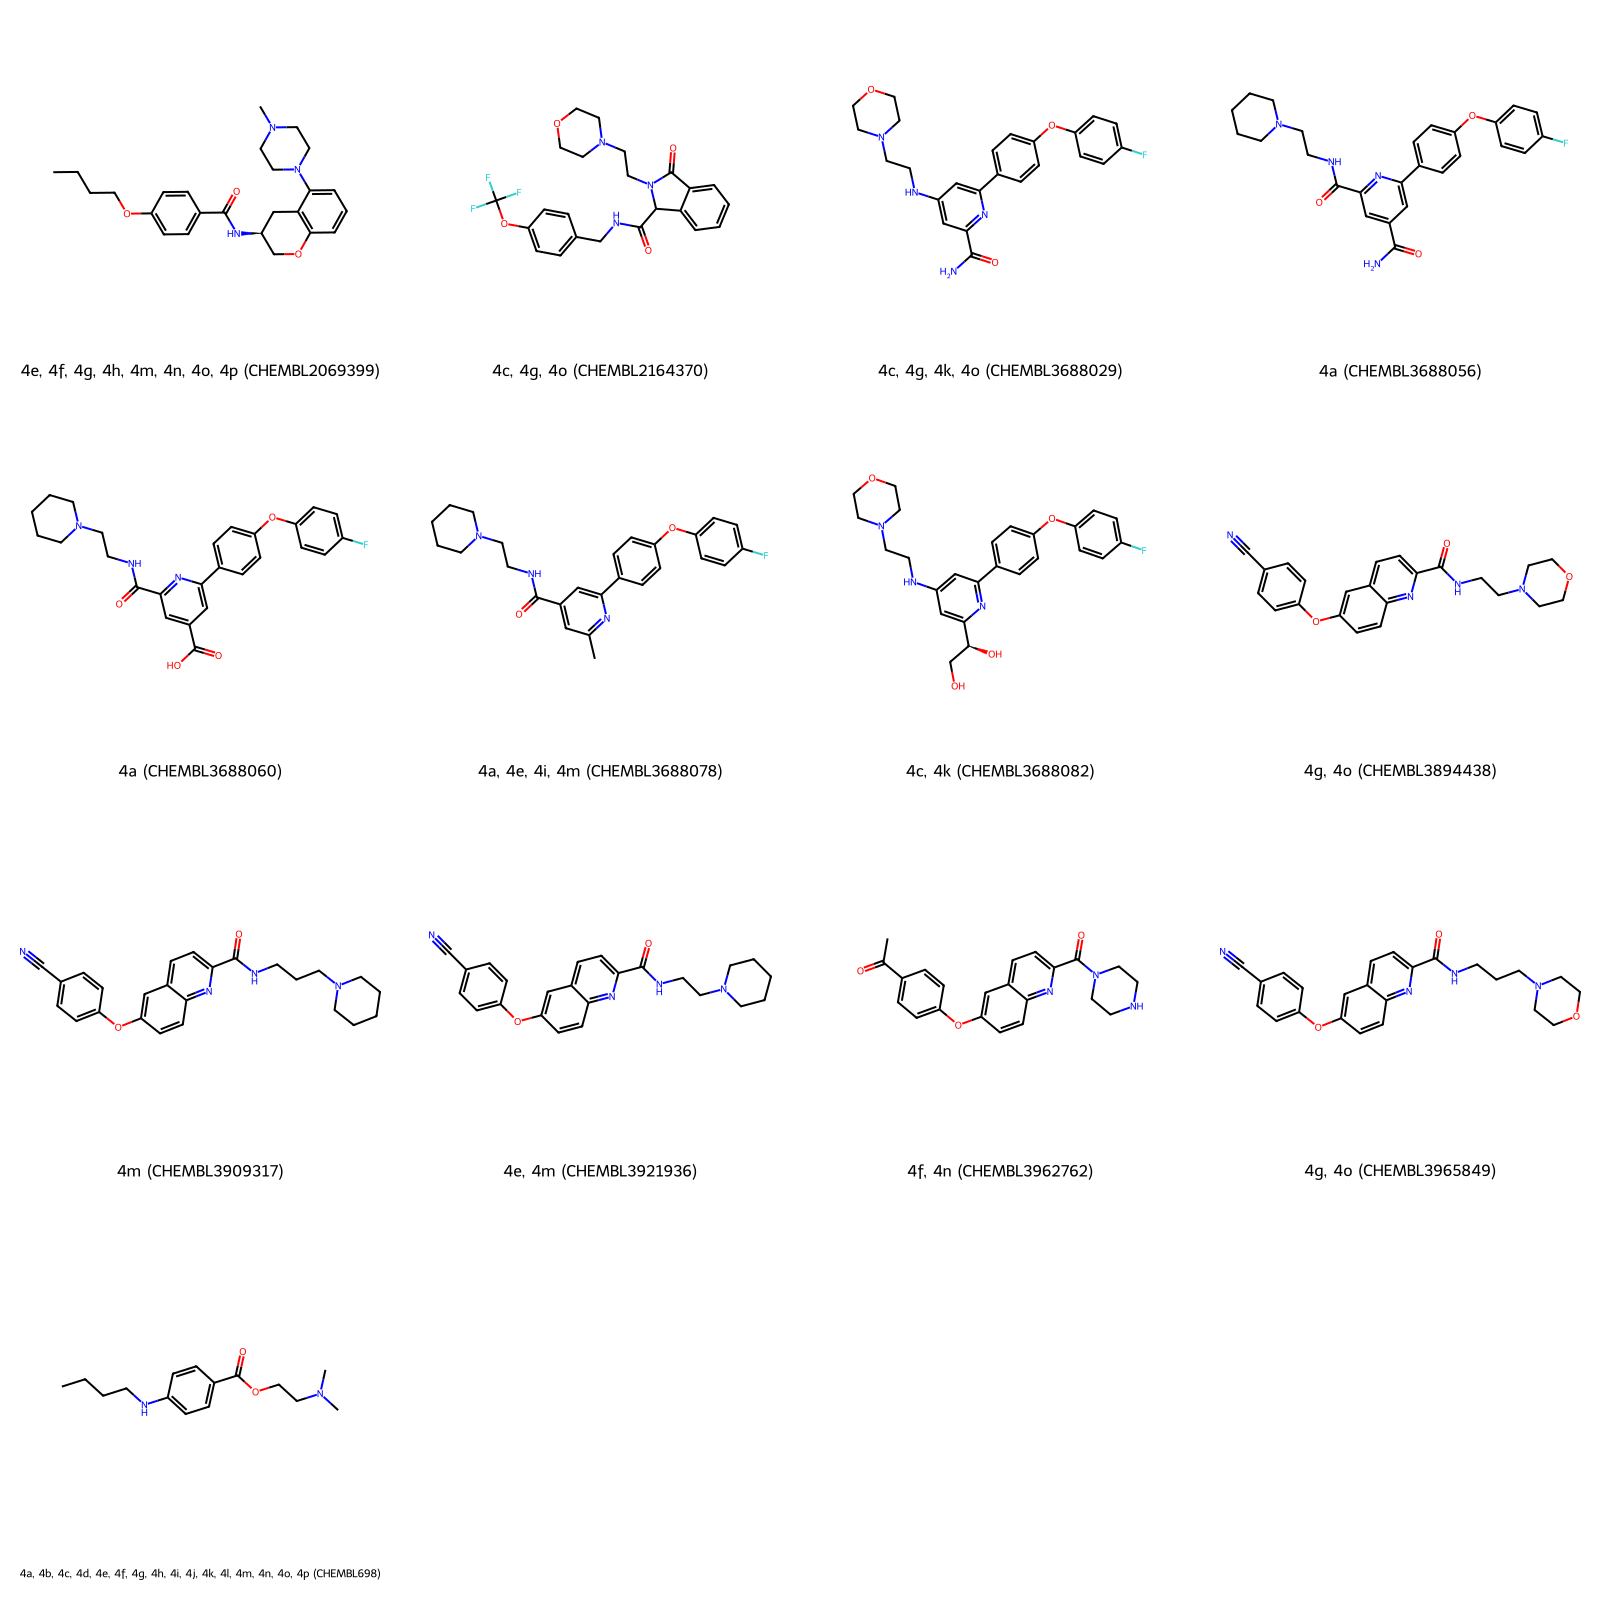

In [9]:
from rdkit import Chem
from rdkit.Chem import Draw
import pandas as pd

# ============================================================
# STEP 7 — Visualize unique matched molecules
# ============================================================

# 1. Group all matches belonging to the same ChEMBL molecule.
#    If one molecule matches multiple reference compounds,
#    combine those reference labels into one label.

unique_mols_df = (
    master_hits_df
    .groupby("molecule_chembl_id", as_index=False)
    .agg({
        "canonical_smiles": "first",
        "query_compound": lambda x: ", ".join(
            sorted(set(x))
        )
    })
)

print(f"Unique ChEMBL molecules identified: {len(unique_mols_df)}")


# 2. Convert SMILES into RDKit molecule objects.

mols_list = []
labels_list = []

failed_smiles_count = 0

for _, row in unique_mols_df.iterrows():

    smiles = row["canonical_smiles"]

    if pd.isna(smiles) or not isinstance(smiles, str):
        failed_smiles_count += 1
        continue

    mol = Chem.MolFromSmiles(smiles)

    if mol is not None:
        mols_list.append(mol)

        # Example:
        # 4a, 4b (CHEMBL698)
        labels_list.append(
            f"{row['query_compound']} "
            f"({row['molecule_chembl_id']})"
        )

    else:
        failed_smiles_count += 1


print(f"Valid molecules drawn: {len(mols_list)}")
print(f"Missing/invalid structures skipped: {failed_smiles_count}")


# 3. Generate a structure grid.

if mols_list:

    img = Draw.MolsToGridImage(
        mols_list,
        molsPerRow=4,
        subImgSize=(400, 400),
        legends=labels_list
    )

    display(img)

else:
    print("ERROR: No valid molecules available for visualization.")

## Step 8 — Manual Application and Validation of the R × X1 × X2 Hypothesis

The structurally similar ChEMBL molecules will now be manually examined to determine whether the **R × X1 × X2 SAR hypothesis** identified from the original 16-compound series can be meaningfully applied.

Each candidate molecule will be evaluated based on its **lipophilic section, link section, and hydrophilic section**. The structural features corresponding to **R, X1, and X2** will then be compared with the original SAR relationships.

The additional ChEMBL molecules will be used to determine whether the proposed SAR relationship is **supported, challenged, or not sufficiently applicable** to the new structures.